## Human Activity Recognition using Random Forest
## IT22341822 - K M H G S A KONARA

**Dataset:** Human Activity Recognition Using Smartphones  
**Source:** https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones  
**Algorithm:** Random Forest Classifier  
**Language:** Python 3  
**Environment:** Jupyter Notebook

## Dataset Description

The Human Activity Recognition (HAR) Using Smartphones dataset was built from experiments carried out with a group of 30 volunteers aged 19–48 years. Each person performed six activities:
| 1 | WALKING |
| 2 | WALKING_UPSTAIRS |
| 3 | WALKING_DOWNSTAIRS |
| 4 | SITTING |
| 5 | STANDING |
| 6 | LAYING |

Wearing a smartphone on the waist, the embedded accelerometer and gyroscope captured:
- 3-axial linear acceleration
- 3-axial angular velocity

Sensor signals were pre-processed and a feature vector of 561 attributes was extracted.
Dataset Size:
- Training set: 7,352 instances
- Test set: 2,947 instances
- Total features: 561
- Classes: 6

## Link: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


### Load the Dataset

In [82]:
BASE_PATH = r"C:\Users\Sadali\Desktop\assignment_ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset"

import os

def load_har_dataset(base_path):
    """
    Load the UCI HAR dataset from the given base path.
    Returns X_train, X_test, y_train, y_test, feature_names, activity_labels.
    """
    # feature names
    features_path = os.path.join(base_path, 'features.txt')
    features = pd.read_csv(features_path, sep='\s+', header=None, names=['idx', 'feature'])
    feature_names = features['feature'].tolist()

    # activity labels
    labels_path = os.path.join(base_path, 'activity_labels.txt')
    activity_labels = pd.read_csv(labels_path, sep='\s+', header=None, names=['id', 'activity'])
    activity_map = dict(zip(activity_labels['id'], activity_labels['activity']))

    # training data
    X_train = pd.read_csv(os.path.join(base_path, 'train', 'X_train.txt'), sep='\s+', header=None)
    y_train = pd.read_csv(os.path.join(base_path, 'train', 'y_train.txt'), sep='\s+', header=None, names=['activity'])

    # test data
    X_test = pd.read_csv(os.path.join(base_path, 'test', 'X_test.txt'), sep='\s+', header=None)
    y_test = pd.read_csv(os.path.join(base_path, 'test', 'y_test.txt'), sep='\s+', header=None, names=['activity'])

    # feature names
    X_train.columns = feature_names
    X_test.columns  = feature_names

    # Map numeric labels to activity names
    y_train['activity'] = y_train['activity'].map(activity_map)
    y_test['activity']  = y_test['activity'].map(activity_map)

    return X_train, X_test, y_train['activity'], y_test['activity'], feature_names, activity_map

# Load the data
X_train, X_test, y_train, y_test, feature_names, activity_map = load_har_dataset(BASE_PATH)

print(f"Training set shape : {X_train.shape}")
print(f"Test set shape     : {X_test.shape}")
print(f"Number of features : {X_train.shape[1]}")
print(f"Activity classes   : {list(activity_map.values())}")

Training set shape : (7352, 561)
Test set shape     : (2947, 561)
Number of features : 561
Activity classes   : ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


## Exploratory Data Analysis (EDA)

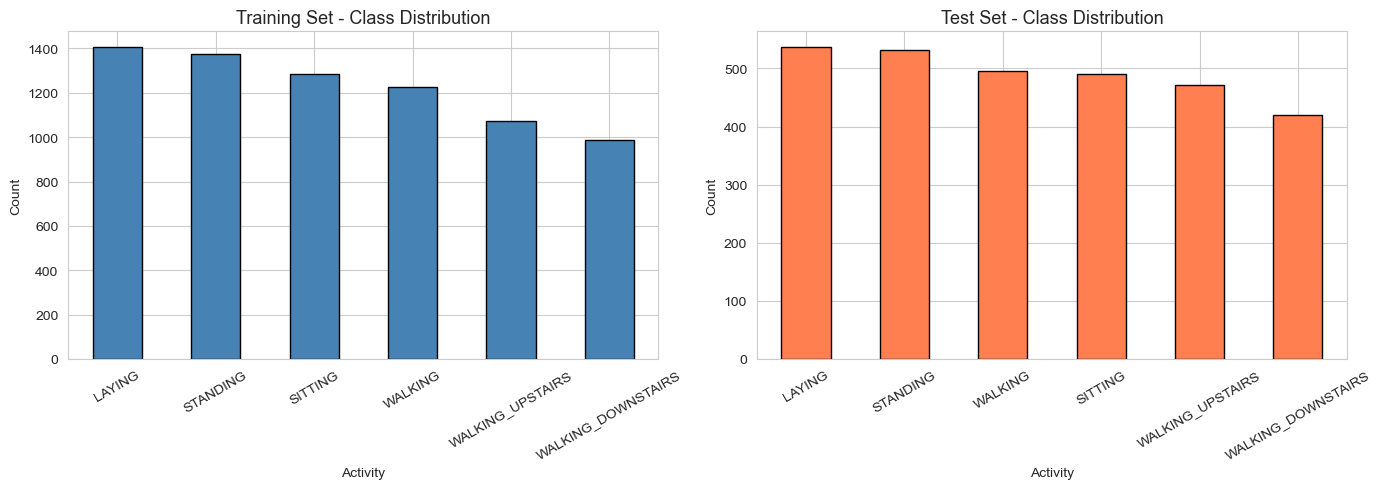


Training Class Distribution:
activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


In [83]:
# ----  Class Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_train.value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Training Set - Class Distribution', fontsize=13)
axes[0].set_xlabel('Activity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

y_test.value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Test Set - Class Distribution', fontsize=13)
axes[1].set_xlabel('Activity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nTraining Class Distribution:")
print(y_train.value_counts())

In [84]:
# ---- Basic Statistics ----
print("Training Data Statistics (first 5 features):")
X_train.iloc[:, :5].describe().round(4)

Training Data Statistics (first 5 features):


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y
count,7352.0000,7352.0000,7352.0000,7352.0000,7352.0000
mean,0.2745,-0.0177,-0.1091,-0.6054,-0.5109
std,0.0703,0.0408,0.0566,0.4487,0.5026
min,-1.0000,-1.0000,-1.0000,-1.0000,-0.9999
25%,0.2630,-0.0249,-0.1210,-0.9928,-0.9781
50%,0.2772,-0.0172,-0.1087,-0.9462,-0.8519
75%,0.2885,-0.0108,-0.0978,-0.2428,-0.0342
max,1.0000,1.0000,1.0000,1.0000,0.9162


In [85]:
# ---- 4.3 Missing Values Check ----
missing_train = X_train.isnull().sum().sum()
missing_test  = X_test.isnull().sum().sum()

print(f"Missing values in training set : {missing_train}")
print(f"Missing values in test set     : {missing_test}")

Missing values in training set : 0
Missing values in test set     : 0


In [86]:
# ---- 4.4 Feature Value Range ----
print(f"Feature value range (train): [{X_train.values.min():.4f}, {X_train.values.max():.4f}]")
print("(Values are already normalized between -1 and 1 by the dataset authors)")

Feature value range (train): [-1.0000, 1.0000]
(Values are already normalized between -1 and 1 by the dataset authors)


## Data Preprocessing

The UCI HAR dataset has been pre-processed by the authors:
- Noise filters applied to sensor signals
- Sliding window segmentation (2.56s windows, 50% overlap)
- Features normalized to [-1, 1]

1. **Duplicate feature name handling** – some feature names repeat; we make them unique
2. **Label encoding** – convert string activity labels to integers for sklearn
3. **Duplicate row check**
4. **Optional PCA** – visualise data in 2D

In [87]:
# ---- 1 Handle Duplicate Feature Names ----
# Some features share the same name; make them unique
seen = {}
unique_names = []
for name in feature_names:
    if name in seen:
        seen[name] += 1
        unique_names.append(f"{name}_{seen[name]}")
    else:
        seen[name] = 0
        unique_names.append(name)

X_train.columns = unique_names
X_test.columns  = unique_names

duplicates = len(feature_names) - len(set(feature_names))
print(f"Duplicate feature names resolved: {duplicates}")

Duplicate feature names resolved: 84


In [88]:
# ---- 2 Label Encoding ----
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label Encoding Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

Label Encoding Mapping:
  0 -> LAYING
  1 -> SITTING
  2 -> STANDING
  3 -> WALKING
  4 -> WALKING_DOWNSTAIRS
  5 -> WALKING_UPSTAIRS


In [89]:
# ---- 3 Check Duplicate Rows ----
dup_train = X_train.duplicated().sum()
dup_test  = X_test.duplicated().sum()
print(f"Duplicate rows in training set : {dup_train}")
print(f"Duplicate rows in test set     : {dup_test}")

Duplicate rows in training set : 0
Duplicate rows in test set     : 0


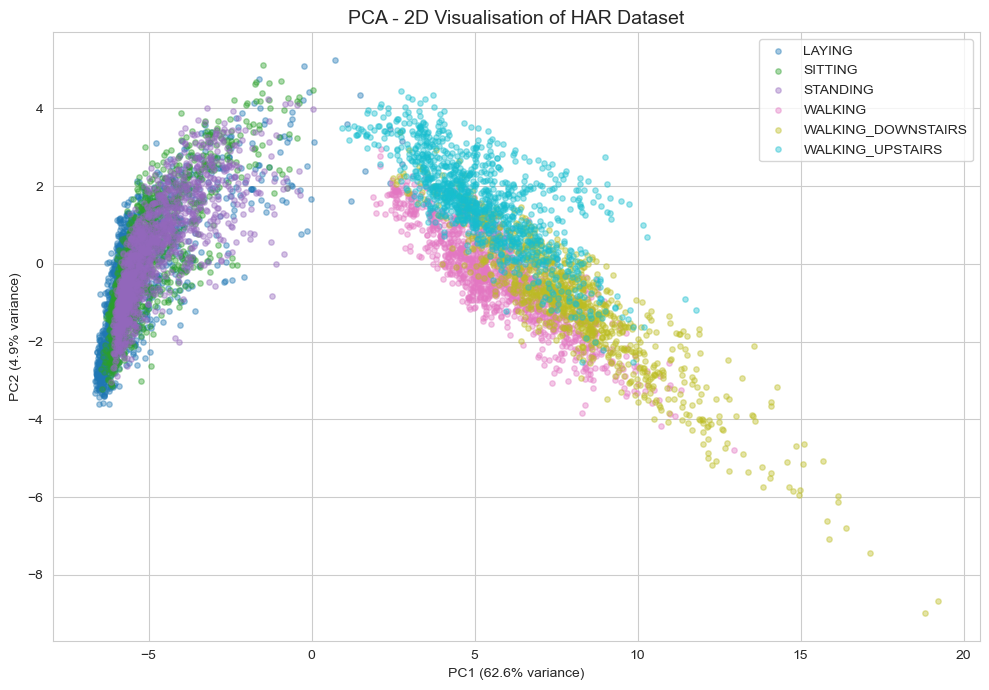

Total variance explained by 2 PCs: 67.47%


In [90]:
# ---- 4 PCA Visualization (2D) ----
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(le.classes_)))

for i, activity in enumerate(le.classes_):
    mask = y_train == activity
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                label=activity, alpha=0.4, s=15, color=colors[i])

plt.title('PCA - 2D Visualisation of HAR Dataset', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## Model Training

In [91]:
# ---- 1 Baseline Random Forest ----
print("Training baseline Random Forest...")

rf_baseline = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_features='sqrt',# sqrt(561) features per split
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

rf_baseline.fit(X_train, y_train_enc)

# Evaluate on test set
y_pred_baseline = rf_baseline.predict(X_test)
acc_baseline = accuracy_score(y_test_enc, y_pred_baseline)

print(f"Baseline RF Test Accuracy: {acc_baseline * 100:.2f}%")

Training baseline Random Forest...
Baseline RF Test Accuracy: 92.67%


In [92]:
# ---- 2 Cross-Validation ----
print("Running 5-Fold Stratified Cross-Validation...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_baseline, X_train, y_train_enc, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"CV Scores     : {[f'{s:.4f}' for s in cv_scores]}")
print(f"CV Mean Acc   : {cv_scores.mean()*100:.2f}%")
print(f"CV Std Dev    : {cv_scores.std()*100:.2f}%")

Running 5-Fold Stratified Cross-Validation...
CV Scores     : ['0.9796', '0.9850', '0.9803', '0.9810', '0.9823']
CV Mean Acc   : 98.16%
CV Std Dev    : 0.19%


## Results and Evaluation

In [93]:
# ---- 1 Classification Report ----
print("Classification Report (Tuned Random Forest):")
print("=" * 60)
print(classification_report(
    y_test_enc, y_pred_baseline,
    target_names=le.classes_
))

Classification Report (Tuned Random Forest):
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



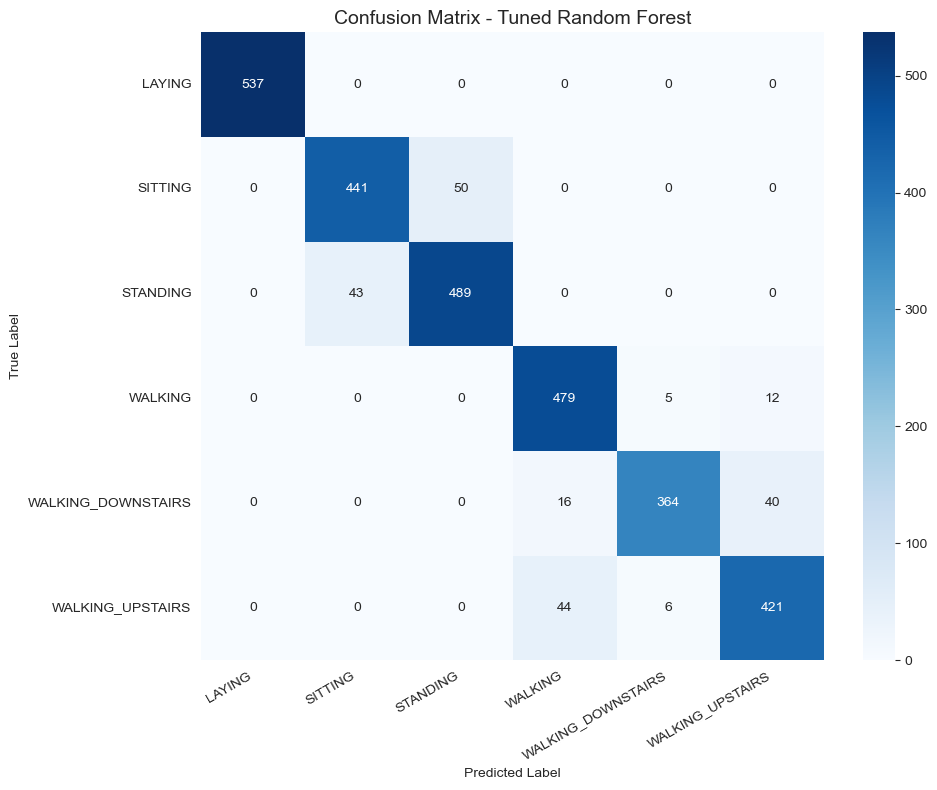

In [94]:
# ---- 2 Confusion Matrix ----
cm = confusion_matrix(y_test_enc, y_pred_baseline)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [95]:
# ---- 3 Per-Class Performance Summary ----
precision = precision_score(y_test_enc, y_pred_baseline, average=None)
recall    = recall_score(y_test_enc, y_pred_baseline, average=None)
f1        = f1_score(y_test_enc, y_pred_baseline, average=None)

results_df = pd.DataFrame({
    'Activity' : le.classes_,
    'Precision': precision.round(4),
    'Recall'   : recall.round(4),
    'F1-Score' : f1.round(4)
})
print(results_df.to_string(index=False))

print(f"\nOverall Accuracy (Baseline) : {acc_baseline*100:.2f}%")
print(f"Macro F1-Score              : {f1_score(y_test_enc, y_pred_baseline, average='macro')*100:.2f}%")

          Activity  Precision  Recall  F1-Score
            LAYING     1.0000  1.0000    1.0000
           SITTING     0.9112  0.8982    0.9046
          STANDING     0.9072  0.9192    0.9132
           WALKING     0.8887  0.9657    0.9256
WALKING_DOWNSTAIRS     0.9707  0.8667    0.9157
  WALKING_UPSTAIRS     0.8901  0.8938    0.8919

Overall Accuracy (Baseline) : 92.67%
Macro F1-Score              : 92.52%


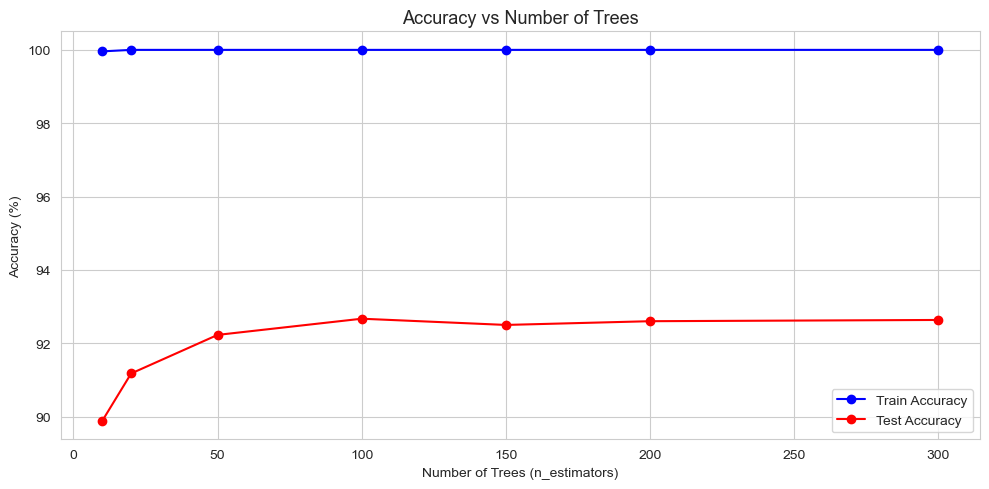

In [96]:
# ---- 4 Effect of Number of Trees on Accuracy ----
n_trees_range = [10, 20, 50, 100, 150, 200, 300]
train_accs, test_accs = [], []

for n in n_trees_range:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train_enc)
    train_accs.append(accuracy_score(y_train_enc, rf_tmp.predict(X_train)))
    test_accs.append(accuracy_score(y_test_enc, rf_tmp.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_range, [a*100 for a in train_accs], 'b-o', label='Train Accuracy')
plt.plot(n_trees_range, [a*100 for a in test_accs],  'r-o', label='Test Accuracy')
plt.title('Accuracy vs Number of Trees', fontsize=13)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

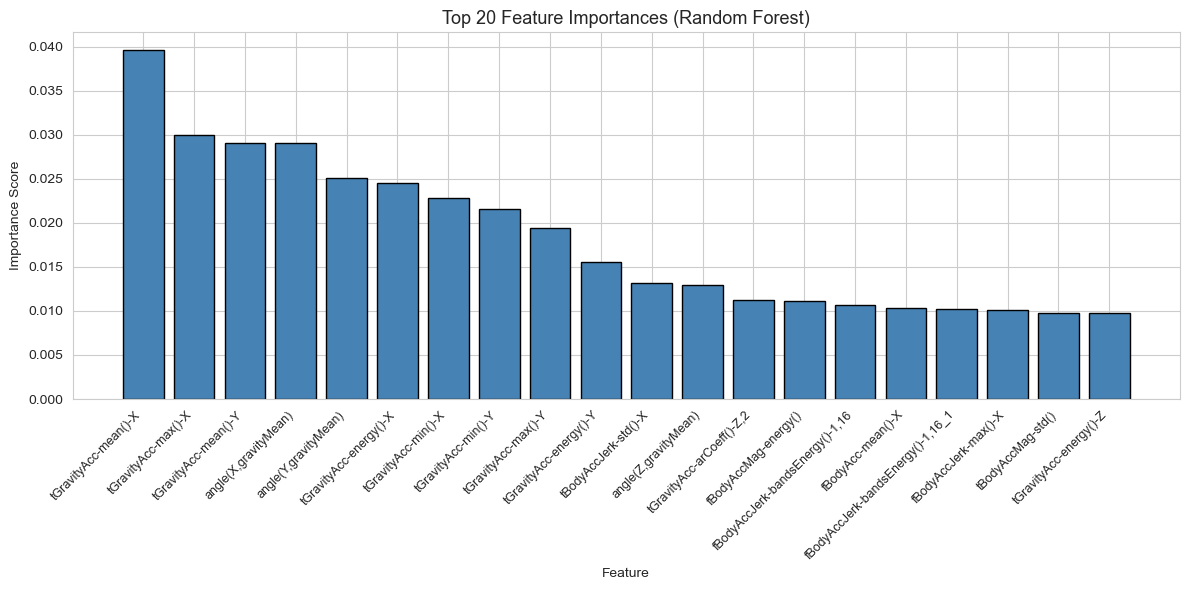


Top 10 Most Important Features:
  1. tGravityAcc-mean()-X                               0.0396
  2. tGravityAcc-max()-X                                0.0300
  3. tGravityAcc-mean()-Y                               0.0291
  4. angle(X,gravityMean)                               0.0291
  5. angle(Y,gravityMean)                               0.0251
  6. tGravityAcc-energy()-X                             0.0246
  7. tGravityAcc-min()-X                                0.0228
  8. tGravityAcc-min()-Y                                0.0216
  9. tGravityAcc-max()-Y                                0.0194
  10. tGravityAcc-energy()-Y                             0.0156


In [97]:
# ---- 5 Feature Importance ----
importances = rf_baseline.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20 features

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(20), [unique_names[i] for i in indices], rotation=45, ha='right', fontsize=9)
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
for i in range(10):
    print(f"  {i+1}. {unique_names[indices[i]]:50s} {importances[indices[i]]:.4f}")

### Results Summary

In [98]:
# ---- Final Summary ----
print("=" * 60)
print("         RANDOM FOREST - FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset         : UCI HAR (Human Activity Recognition)")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Test samples    : {X_test.shape[0]}")
print(f"  Features        : {X_train.shape[1]}")
print(f"  Classes         : {len(le.classes_)} ({', '.join(le.classes_)})")
print("-" * 60)
print(f"  Baseline Accuracy (100 trees)  : {acc_baseline*100:.2f}%")
print(f"  CV Mean Accuracy (5-fold)      : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"  Macro F1-Score                 : {f1_score(y_test_enc, y_pred_baseline, average='macro')*100:.2f}%")
print("=" * 60)

         RANDOM FOREST - FINAL RESULTS SUMMARY
  Dataset         : UCI HAR (Human Activity Recognition)
  Training samples: 7352
  Test samples    : 2947
  Features        : 561
  Classes         : 6 (LAYING, SITTING, STANDING, WALKING, WALKING_DOWNSTAIRS, WALKING_UPSTAIRS)
------------------------------------------------------------
  Baseline Accuracy (100 trees)  : 92.67%
  CV Mean Accuracy (5-fold)      : 98.16% ± 0.19%
  Macro F1-Score                 : 92.52%
